In [9]:
import sys
import os
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Phase 0-5: Panel Diagnostics
This notebook executes the first part of the panel econometrics workflow.

In [10]:
import pandas as pd
import numpy as np
from src.config import PROCESSED_PANEL_FILE
from src.model_contract import MODEL_BLUEPRINTS, build_model_frame, map_blueprint_variables
from src.panel_diagnostics import *

# Load Data
df = pd.read_csv(PROCESSED_PANEL_FILE)

# Add Lags
def add_lags(frame: pd.DataFrame) -> pd.DataFrame:
    lagged = frame.copy()
    columns_to_lag = [
        'fdi_pct_gdp', 'broad_money_pct_gdp', 'deposit_interest_rate_pct',
        'real_interest_rate_pct', 'lending_interest_rate_pct', 'inflation_gdp_deflator_pct',
        'ln_gdppc', 'trade_pct_gdp', 'xr_dep_pct', 'ln_population_total', 'ln_tourism_arrivals',
        'hc_human_capital_index'
    ]
    for col in columns_to_lag:
        if col in lagged.columns:
            lagged[f"{col}_lag1"] = lagged.groupby("country")[col].shift(1)
    return lagged

df = add_lags(df)
df.head()

,country_id,country_code,country,year,fdi_pct_gdp,fdi_pct_gdp_winsorized,broad_money_pct_gdp,trade_pct_gdp,inflation_gdp_deflator_pct,deposit_interest_rate_pct,...,deposit_interest_rate_pct_lag1,real_interest_rate_pct_lag1,lending_interest_rate_pct_lag1,inflation_gdp_deflator_pct_lag1,ln_gdppc_lag1,trade_pct_gdp_lag1,xr_dep_pct_lag1,ln_population_total_lag1,ln_tourism_arrivals_lag1,hc_human_capital_index_lag1
0,1,BRN,Brunei Darussalam,2010,3.507101,3.507101,67.271968,95.371546,4.980090,0.470541,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,BRN,Brunei Darussalam,2011,3.731056,3.731056,59.380496,99.537931,20.180769,0.395687,...,0.470541,0.495247,5.5,4.980090,10.461318,95.371546,NaN,12.879864,15.264075,2.696971
2,1,BRN,Brunei Darussalam,2012,4.540558,4.540558,58.656468,105.640902,1.220252,0.231537,...,0.395687,-12.215572,5.5,20.180769,10.744685,99.537931,-8.060786,12.897691,15.264075,2.721460
3,1,BRN,Brunei Darussalam,2013,4.286701,4.286701,62.575389,110.939600,-2.823490,0.284347,...,0.231537,4.228154,5.5,1.220252,10.757235,105.640902,-0.665691,12.913017,15.264075,2.732495
4,1,BRN,Brunei Darussalam,2014,3.356609,3.356609,67.498596,102.421001,-1.846015,0.300000,...,0.284347,8.565331,5.5,-2.823490,10.692015,110.939600,0.127855,12.926840,15.264075,2.743649


## Phase 0: Variable Audit & Multicollinearity

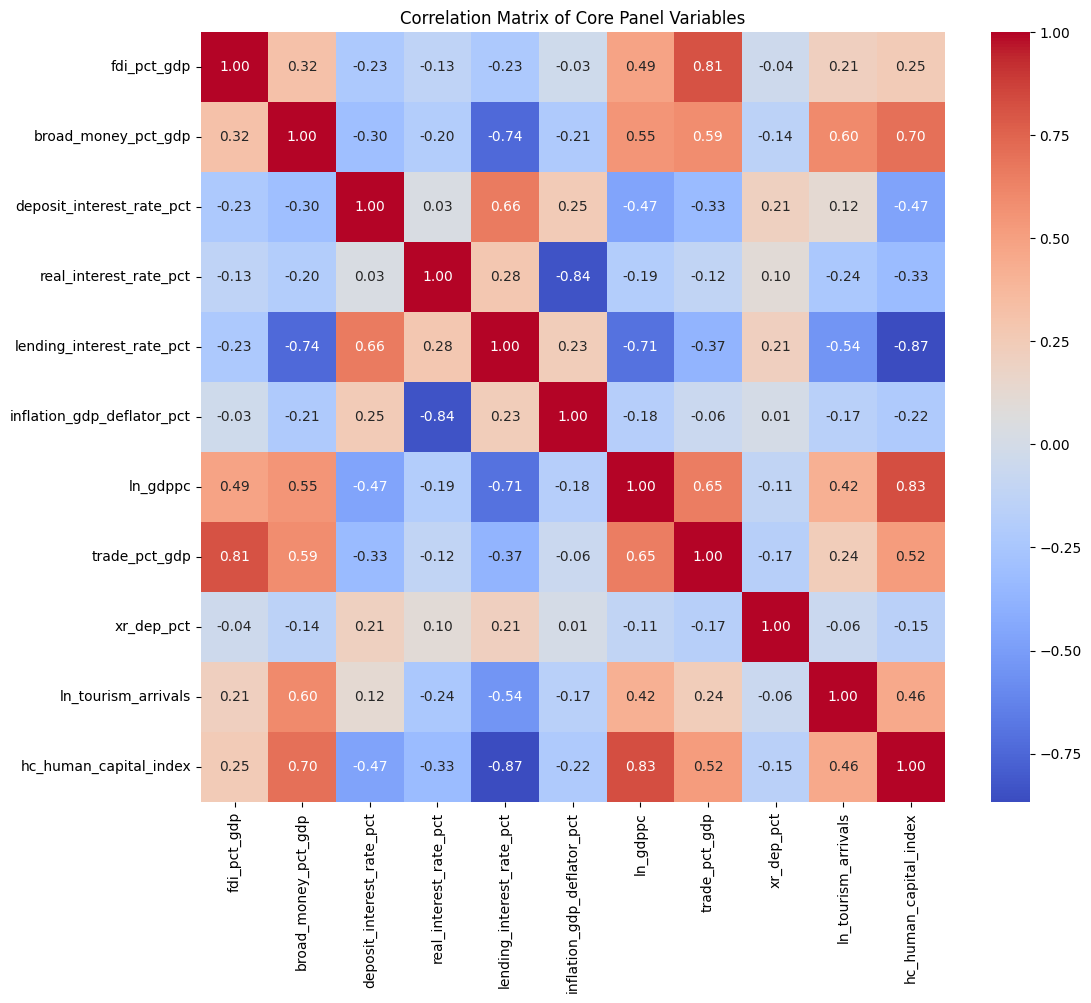


VIF Table for M1 - Baseline liquidity (M1_baseline_liquidity)
  specification                    variable        vif
0            M1    broad_money_pct_gdp_lag1  10.789662
1            M1  inflation_gdp_deflator_pct   1.132689
2            M1               trade_pct_gdp   6.377842
3            M1                    ln_gdppc   9.217881
4            M1                  xr_dep_pct   1.134801

VIF Table for M2 - Deposit-rate channel (M2_main_monetary_policy)
  specification                        variable        vif
0            M2             broad_money_pct_gdp  11.261435
1            M2  deposit_interest_rate_pct_lag1   2.090897
2            M2      inflation_gdp_deflator_pct   1.180252
3            M2                   trade_pct_gdp   6.481544
4            M2                        ln_gdppc  10.433794
5            M2                      xr_dep_pct   1.193330

VIF Table for M3 - Lagged deposit-rate robustness (M3_lagged_main_model)
  specification                    variable        vi

In [11]:
from src.panel_diagnostics import vif_table
import seaborn as sns
import matplotlib.pyplot as plt

variables = [
    'fdi_pct_gdp', 'broad_money_pct_gdp', 'deposit_interest_rate_pct',
    'real_interest_rate_pct', 'lending_interest_rate_pct', 'inflation_gdp_deflator_pct',
    'ln_gdppc', 'trade_pct_gdp', 'xr_dep_pct', 'ln_tourism_arrivals',
    'hc_human_capital_index'
]
corr = df[variables].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Core Panel Variables')
plt.show()

for bp in MODEL_BLUEPRINTS:
    regressors = map_blueprint_variables(bp, lagged=bp.lagged)
    model_df = build_model_frame(df, 'fdi_pct_gdp', regressors, exclude_countries=bp.exclude_countries)
    print(f"\n==================================================")
    print(f"VIF Table for {bp.workbook_label} ({bp.model_id})")
    print(f"==================================================")
    print(vif_table(model_df, bp.workbook_code, regressors))

## Phase 1: Cross-Sectional Dependence

In [12]:
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
from src.panel_diagnostics import pesaran_cd_test

print("Pesaran CD Test for all models:")
for bp in MODEL_BLUEPRINTS:
    regressors = map_blueprint_variables(bp, lagged=bp.lagged)
    model_df = build_model_frame(df, 'fdi_pct_gdp', regressors, exclude_countries=bp.exclude_countries)
    y = model_df['fdi_pct_gdp']
    X = add_constant(model_df[regressors], has_constant='add')
    pooled_model = OLS(y, X).fit()
    cd_result = pesaran_cd_test(pooled_model.resid, bp.workbook_code)
    
    print(f"\nBlueprint: {bp.model_id} ({bp.workbook_code})")
    for k, v in cd_result.items():
        print(f"  {k}: {v}")

Pesaran CD Test for all models:

Blueprint: M1_baseline_liquidity (M1)
  specification: M1
  pesaran_cd_stat: 0.4670057809210948
  pesaran_cd_p_value: 0.6404957420853101
  pesaran_cd_country_pairs: 36
  pesaran_cd_min_pair_years: 11
  pesaran_cd_max_pair_years: 13

Blueprint: M2_main_monetary_policy (M2)
  specification: M2
  pesaran_cd_stat: 0.662400685388421
  pesaran_cd_p_value: 0.5077144645782297
  pesaran_cd_country_pairs: 28
  pesaran_cd_min_pair_years: 10
  pesaran_cd_max_pair_years: 13

Blueprint: M3_lagged_main_model (M3)
  specification: M3
  pesaran_cd_stat: 0.8471694614031914
  pesaran_cd_p_value: 0.3969006726789768
  pesaran_cd_country_pairs: 28
  pesaran_cd_min_pair_years: 9
  pesaran_cd_max_pair_years: 13

Blueprint: M4_real_interest_robustness (M4)
  specification: M4
  pesaran_cd_stat: 1.4770009906679156
  pesaran_cd_p_value: 0.13967537172189104
  pesaran_cd_country_pairs: 28
  pesaran_cd_min_pair_years: 9
  pesaran_cd_max_pair_years: 13

Blueprint: M5_lending_rate_rob

## Phase 2: Panel Unit Root Test

In [13]:
from src.panel_diagnostics import pooled_adf_test

# Define variables and their appropriate panels
full_panel_vars = [
    'fdi_pct_gdp', 'broad_money_pct_gdp', 'inflation_gdp_deflator_pct',
    'trade_pct_gdp', 'ln_gdppc', 'xr_dep_pct'
]
restricted_panel_vars = [
    'deposit_interest_rate_pct', 'real_interest_rate_pct',
    'lending_interest_rate_pct', 'ln_tourism_arrivals', 'hc_human_capital_index'
]

print("=== Pooled Unit Root Test Results (Augmented Dickey-Fuller) ===")

print("\n--- Full Panel ---")
for v in full_panel_vars:
    res = pooled_adf_test(df, v)
    if "error" in res:
        print(f"{v}: Error: {res['error']}")
    else:
        crit_str = ", ".join([f"{k}: {v:.3f}" for k, v in res['critical_values'].items()])
        print(f"{v}: stat={res['statistic']:.4f}, p-value={res['p_value']:.4f}, lags={res['usedlag']}, nobs={res['nobs']}, crit=({crit_str})")

print("\n--- Restricted Panel (Excluding Cambodia and Lao PDR) ---")
restricted_df = df[~df['country'].isin(['Cambodia', 'Lao PDR'])].copy()
for v in restricted_panel_vars:
    res = pooled_adf_test(restricted_df, v)
    if "error" in res:
        print(f"{v}: Error: {res['error']}")
    else:
        crit_str = ", ".join([f"{k}: {v:.3f}" for k, v in res['critical_values'].items()])
        print(f"{v}: stat={res['statistic']:.4f}, p-value={res['p_value']:.4f}, lags={res['usedlag']}, nobs={res['nobs']}, crit=({crit_str})")

=== Pooled Unit Root Test Results (Augmented Dickey-Fuller) ===

--- Full Panel ---
fdi_pct_gdp: stat=-3.5292, p-value=0.0073, lags=0, nobs=153, crit=(1%: -3.474, 5%: -2.881, 10%: -2.577)
broad_money_pct_gdp: stat=-2.8150, p-value=0.0562, lags=0, nobs=132, crit=(1%: -3.481, 5%: -2.884, 10%: -2.579)
inflation_gdp_deflator_pct: stat=-5.8744, p-value=0.0000, lags=2, nobs=151, crit=(1%: -3.474, 5%: -2.881, 10%: -2.577)
trade_pct_gdp: stat=-1.9504, p-value=0.3087, lags=14, nobs=125, crit=(1%: -3.484, 5%: -2.885, 10%: -2.579)
ln_gdppc: stat=-2.9244, p-value=0.0426, lags=0, nobs=153, crit=(1%: -3.474, 5%: -2.881, 10%: -2.577)
xr_dep_pct: stat=-11.0885, p-value=0.0000, lags=0, nobs=142, crit=(1%: -3.477, 5%: -2.882, 10%: -2.578)

--- Restricted Panel (Excluding Cambodia and Lao PDR) ---
deposit_interest_rate_pct: stat=-2.9664, p-value=0.0382, lags=2, nobs=114, crit=(1%: -3.489, 5%: -2.887, 10%: -2.580)
real_interest_rate_pct: stat=-5.3739, p-value=0.0000, lags=2, nobs=113, crit=(1%: -3.490, 5%

## Phase 3: Cointegration

In [14]:
from src.panel_diagnostics import pooled_engle_granger_test

print("=== Pooled Cointegration Test Results (Engle-Granger Two-Step) ===")
for bp in MODEL_BLUEPRINTS:
    regressors = map_blueprint_variables(bp, lagged=bp.lagged)
    print(f"\nBlueprint: {bp.model_id} ({bp.workbook_code})")
    res = pooled_engle_granger_test(
        df,
        dependent='fdi_pct_gdp',
        regressors=regressors,
        exclude_countries=bp.exclude_countries
    )
    if "error" in res:
        print(f"  Error: {res['error']}")
    else:
        print(f"  Tested regressors: {res['tested_regressors']}")
        print(f"  Observations: {res['nobs']}")
        crit_str = ", ".join([f"{k}: {v:.3f}" for k, v in res['critical_values'].items()])
        print(f"  t-statistic: {res['statistic']:.4f}")
        print(f"  p-value: {res['p_value']:.4f}")
        print(f"  Critical values: {crit_str}")

=== Pooled Cointegration Test Results (Engle-Granger Two-Step) ===

Blueprint: M1_baseline_liquidity (M1)
  Tested regressors: ['broad_money_pct_gdp_lag1', 'inflation_gdp_deflator_pct', 'trade_pct_gdp', 'ln_gdppc', 'xr_dep_pct']
  Observations: 116
  t-statistic: -6.0746
  p-value: 0.0004
  Critical values: 1%: -5.473, 5%: -4.855, 10%: -4.540

Blueprint: M2_main_monetary_policy (M2)
  Tested regressors: ['broad_money_pct_gdp', 'deposit_interest_rate_pct_lag1', 'inflation_gdp_deflator_pct', 'trade_pct_gdp', 'ln_gdppc', 'xr_dep_pct']
  Observations: 97
  t-statistic: -5.6284
  p-value: nan
  Critical values: 1%: -5.828, 5%: -5.186, 10%: -4.861

Blueprint: M3_lagged_main_model (M3)
  Tested regressors: ['broad_money_pct_gdp', 'deposit_interest_rate_pct', 'inflation_gdp_deflator_pct', 'trade_pct_gdp', 'ln_gdppc', 'xr_dep_pct']
  Observations: 96
  t-statistic: -5.6877
  p-value: nan
  Critical values: 1%: -5.831, 5%: -5.189, 10%: -4.863

Blueprint: M4_real_interest_robustness (M4)
  Tested

## Phase 4: Hausman Test

In [15]:
from linearmodels.panel import PanelOLS, RandomEffects
from src.panel_diagnostics import hausman_test
from statsmodels.tools.tools import add_constant

print("=== Hausman Test (FE vs RE) ===")
for bp in MODEL_BLUEPRINTS:
    regressors = map_blueprint_variables(bp, lagged=bp.lagged)
    model_df = build_model_frame(df, 'fdi_pct_gdp', regressors, exclude_countries=bp.exclude_countries)
    y = model_df['fdi_pct_gdp']
    X = add_constant(model_df[regressors], has_constant='add')
    
    # Fit FE and RE models
    fe_model = PanelOLS(y, X, entity_effects=True).fit()
    try:
        re_model = RandomEffects(y, X).fit()
        haus = hausman_test(fe_model, re_model, regressors)
        print(f"\nBlueprint: {bp.model_id} ({bp.workbook_code})")
        print(f"  Statistic: {haus['statistic']:.4f}")
        print(f"  p-value: {haus['p_value']:.4f}")
        print(f"  Degrees of freedom: {haus['degrees_of_freedom']}")
        print(f"  Negative statistic flag: {haus['negative_statistic_flag']}")
    except (ZeroDivisionError, ValueError) as exc:
        print(f"\nBlueprint: {bp.model_id} ({bp.workbook_code})")
        print(f"  Hausman test could not be run: RE fit failed ({exc})")

=== Hausman Test (FE vs RE) ===

Blueprint: M1_baseline_liquidity (M1)
  Statistic: 31.0322
  p-value: 0.0000
  Degrees of freedom: 5
  Negative statistic flag: False

Blueprint: M2_main_monetary_policy (M2)
  Statistic: 33.8105
  p-value: 0.0000
  Degrees of freedom: 6
  Negative statistic flag: False

Blueprint: M3_lagged_main_model (M3)
  Statistic: 34.3747
  p-value: 0.0000
  Degrees of freedom: 6
  Negative statistic flag: False

Blueprint: M4_real_interest_robustness (M4)
  Statistic: 35.9995
  p-value: 0.0000
  Degrees of freedom: 5
  Negative statistic flag: False

Blueprint: M5_lending_rate_robustness (M5)
  Statistic: 49.7520
  p-value: 0.0000
  Degrees of freedom: 6
  Negative statistic flag: False

Blueprint: M6a_tourism_robustness_from_M2 (M6)
  Hausman test could not be run: RE fit failed (float division by zero)

Blueprint: M6b_tourism_robustness_from_M4 (M6)
  Statistic: 0.0000
  p-value: 1.0000
  Degrees of freedom: 6
  Negative statistic flag: True

Blueprint: M7a_hum

## Phase 5: Within-Model Diagnostics

In [16]:
from src.panel_diagnostics import r_wooldridge_serial_correlation_test, pooled_model_diagnostics
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

print("=== Within-Model Diagnostics (Serial Correlation & Heteroskedasticity) ===")
for bp in MODEL_BLUEPRINTS:
    regressors = map_blueprint_variables(bp, lagged=bp.lagged)
    model_df = build_model_frame(df, 'fdi_pct_gdp', regressors, exclude_countries=bp.exclude_countries)
    y = model_df['fdi_pct_gdp']
    X = add_constant(model_df[regressors], has_constant='add')
    pooled_model = OLS(y, X).fit()
    
    serial = r_wooldridge_serial_correlation_test(df, 'fdi_pct_gdp', regressors)
    het = pooled_model_diagnostics(pooled_model, model_df, bp.workbook_code, regressors)
    
    print(f"\nBlueprint: {bp.model_id} ({bp.workbook_code})")
    if "error" in serial:
        print(f"  Wooldridge Serial Correlation: Error: {serial['error']}")
    else:
        print(f"  Wooldridge Serial Correlation: statistic={serial.get('statistic', 'N/A')}, p-value={serial.get('p_value', 'N/A')}")
    print(f"  Breusch-Pagan Heteroskedasticity LM p-value: {het['breusch_pagan_lm_p_value']:.4f}")
    print(f"  White Heteroskedasticity LM p-value: {het['white_lm_p_value']:.4f}")
    print(f"  Condition Number: {het['condition_number']:.4f}")

=== Within-Model Diagnostics (Serial Correlation & Heteroskedasticity) ===



Blueprint: M1_baseline_liquidity (M1)
  Wooldridge Serial Correlation: statistic=31.980673638777652, p-value=1.5571406354791663e-08
  Breusch-Pagan Heteroskedasticity LM p-value: 0.1485
  White Heteroskedasticity LM p-value: 0.0001
  Condition Number: 1428.2065

Blueprint: M2_main_monetary_policy (M2)
  Wooldridge Serial Correlation: statistic=41.90366857269477, p-value=7.800473769361172e-06
  Breusch-Pagan Heteroskedasticity LM p-value: 0.0279
  White Heteroskedasticity LM p-value: 0.0003
  Condition Number: 1741.3094

Blueprint: M3_lagged_main_model (M3)
  Wooldridge Serial Correlation: statistic=41.9309433876904, p-value=3.383462297135261e-06
  Breusch-Pagan Heteroskedasticity LM p-value: 0.0294
  White Heteroskedasticity LM p-value: 0.0003
  Condition Number: 1737.5561

Blueprint: M4_real_interest_robustness (M4)
  Wooldridge Serial Correlation: statistic=29.679917195423428, p-value=0.0009662055513345435
  Breusch-Pagan Heteroskedasticity LM p-value: 0.0719
  White Heteroskedastic